# COMP0198 Coursework – Machine Learning Pipeline

This notebook accompanies the COMP0198 coursework report and documents the full
experimental workflow, including data preprocessing, model training, optimisation,
and evaluation. All experiments are conducted in a reproducible manner and align
with the methodologies discussed in the course lectures and workshops.

The objective is to compare three classification models:
- Logistic Regression
- Random Forest
- Artificial Neural Network

and identify the most suitable model for a financial decision-making task.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 38


## 1. Data Loading

The dataset is provided by the course instructor (CSV). We load it and perform basic integrity checks.


In [2]:
import pandas as pd

df = pd.read_csv("Dataset_2526.csv")

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,empl_len,ppl_household,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,0,3,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0,0,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,3,1,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,0,1,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1,0,1


### Exploratory Statistics and Outliers


Summary statistics were examined to assess the presence of extreme values.
In financial credit data, observations such as high income or long credit
history are not necessarily data errors, but may represent genuinely low-risk
borrowers. Consequently, no outlier removal or winsorisation was applied.
Instead, models that are robust to scale and distributional skewness were
preferred where appropriate.


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
empl_len,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
ppl_household,45000.0,1.303956,1.140329,0.00,0.00,1.00,2.00,8.00


In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

missing = df.isnull().sum().sort_values(ascending=False)
print("\nTop missing columns:\n", missing[missing > 0].head(20))


Shape: (45000, 16)

Columns:
 ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'empl_len', 'ppl_household', 'loan_status']

Top missing columns:
 Series([], dtype: int64)


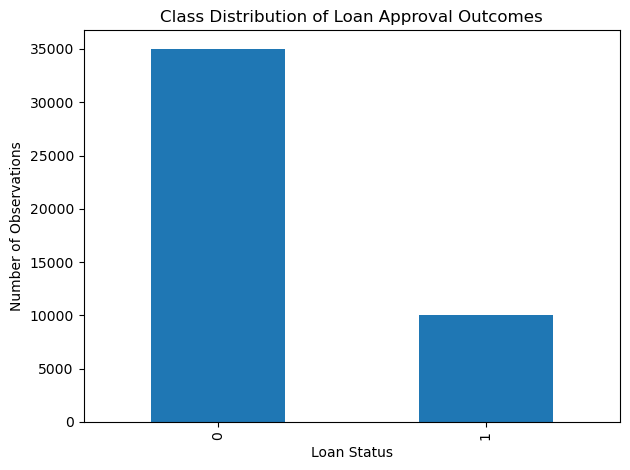

In [5]:
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure()
df['loan_status'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Loan Status')
plt.ylabel('Number of Observations')
plt.title('Class Distribution of Loan Approval Outcomes')
plt.tight_layout()
plt.show()


## 2. Train/Test Split and Leakage-Safe Preprocessing

Target variable: `loan_status` (binary classification).

We use a stratified split to preserve class balance.
Categorical variables are one-hot encoded; numerical variables are standardised **within a pipeline**
to avoid data leakage.


In [6]:
from sklearn.model_selection import train_test_split

target = "loan_status"
X = df.drop(columns=[target])
y = df[target].astype(int)  # ensure binary 0/1 integer

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Target mean (overall):", y.mean())
print("Target mean (train):  ", y_train.mean())
print("Target mean (test):   ", y_test.mean())


Train shape: (36000, 15)  Test shape: (9000, 15)
Target mean (overall): 0.2222222222222222
Target mean (train):   0.2222222222222222
Target mean (test):    0.2222222222222222


## 3. Baseline Model (DummyClassifier)

We benchmark performance against a naive strategy.
Primary metric: ROC-AUC (threshold-independent).


In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_probs = dummy.predict_proba(X_test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_probs)

print("Dummy ROC-AUC:", round(dummy_auc, 4))


Dummy ROC-AUC: 0.5


## 4. Preprocessing Pipeline

Categorical variables are one-hot encoded.
Numerical variables are standardised.

All preprocessing is performed inside a pipeline to prevent data leakage.


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

categorical_cols, numerical_cols


(['person_gender',
  'person_education',
  'person_home_ownership',
  'loan_intent',
  'previous_loan_defaults_on_file'],
 ['person_age',
  'person_income',
  'person_emp_exp',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'credit_score',
  'empl_len',
  'ppl_household'])

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)
, categorical_cols)
    ]
)


## 5. Logistic Regression (Baseline Linear Model)

Logistic Regression with L2 regularisation is used as a transparent baseline.
Hyperparameter tuning is performed via cross-validation using ROC-AUC.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['person_age',
                                                                          'person_income',
                                                                          'person_emp_exp',
                                                                          'loan_amnt',
                                                                          'loan_int_rate',
                                                                          'loan_percent_income',
                                                                          'cb_person_cred_hist_length',
                                                                          'credit_score',
                                                                          'empl_len',
                                                                          'ppl_household']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['person_gender',
                                                                          'person_education',
                                                                          'person_home_ownership',
                                                                          'loan_intent',
                                                                          'previous_loan_defaults_on_file'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=38,
                                                           solver='liblinear'))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10]},
             scoring='roc_auc')

In [11]:
best_lr = grid_lr.best_estimator_

lr_probs = best_lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

print("Best C:", grid_lr.best_params_)
print("Logistic Regression ROC-AUC:", round(lr_auc, 4))


Best C: {'model__C': 10}
Logistic Regression ROC-AUC: 0.9503


## 6. Random Forest (Non-linear Ensemble Model)

Random Forest is trained to capture non-linear feature interactions.
Tree-based models do not require feature scaling.
Hyperparameters controlling tree complexity are tuned via cross-validation.


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Preprocessor WITHOUT scaling for numerical features
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

pipe_rf = Pipeline(
    steps=[
        ("preprocess", preprocessor_rf),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)


In [13]:
param_grid_rf = {
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['person_age',
                                                                          'person_income',
                                                                          'person_emp_exp',
                                                                          'loan_amnt',
                                                                          'loan_int_rate',
                                                                          'loan_percent_income',
                                                                          'cb_person_cred_hist_length',
                                                                          'credit_score',
                                                                          'empl_len',
                                                                          'ppl_household']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['person_gender',
                                                                          'person_education',
                                                                          'person_home_ownership',
                                                                          'loan_intent',
                                                                          'previous_loan_defaults_on_file'])])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=300,
                                                               n_jobs=-1,
                                                               random_state=38))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 5, 10]},
             scoring='roc_auc')

The number of features considered at each split was tuned to control tree
correlation and reduce overfitting in the ensemble.


In [14]:
best_rf = grid_rf.best_estimator_

rf_probs = best_rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

print("Best RF params:", grid_rf.best_params_)
print("Random Forest ROC-AUC:", round(rf_auc, 4))


Best RF params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1}
Random Forest ROC-AUC: 0.9713


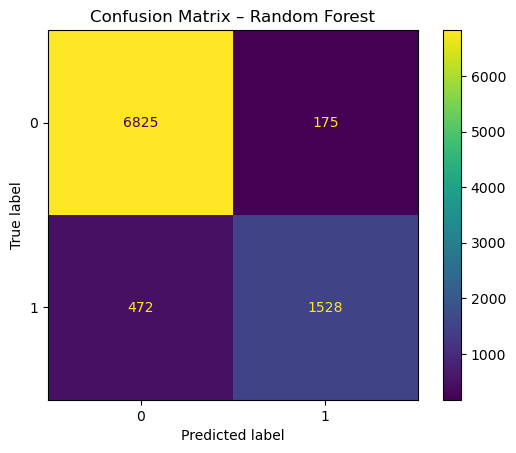

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Random Forest")
plt.show()


The confusion matrix highlights the asymmetric costs of misclassification.
False negatives correspond to high-risk applicants incorrectly approved,
potentially leading to credit losses, while false positives represent rejected
low-risk applicants, implying opportunity costs.


In [16]:
import pandas as pd

importances = best_rf.named_steps["model"].feature_importances_
feature_names = best_rf.named_steps["preprocess"].get_feature_names_out()

fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

fi


,feature,importance
5,num__loan_percent_income,0.152147
4,num__loan_int_rate,0.147351
27,cat__previous_loan_defaults_on_file_No,0.141605
28,cat__previous_loan_defaults_on_file_Yes,0.124190
1,num__person_income,0.105186
3,num__loan_amnt,0.051813
7,num__credit_score,0.046063
20,cat__person_home_ownership_RENT,0.040105
0,num__person_age,0.023185
6,num__cb_person_cred_hist_length,0.019634


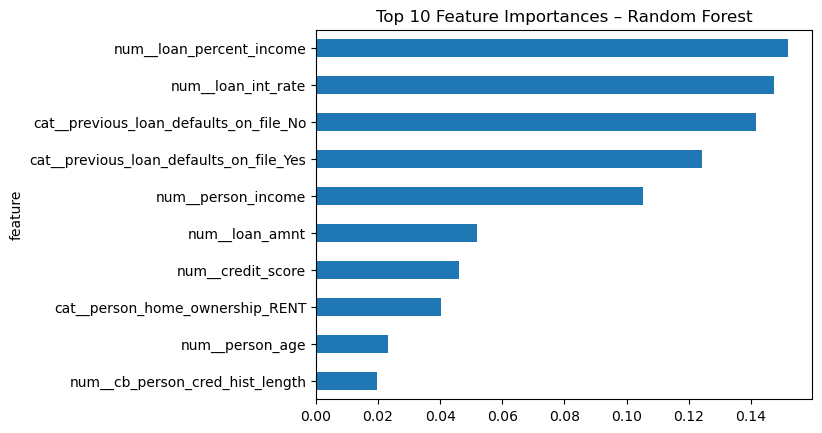

In [17]:
fi.plot(kind="barh", x="feature", y="importance", legend=False)
plt.title("Top 10 Feature Importances – Random Forest")
plt.gca().invert_yaxis()
plt.show()


Credit score and income-related variables dominate feature importance,
which aligns with established credit risk theory.


## 7. Artificial Neural Network (Multilayer Perceptron)

An Artificial Neural Network is implemented using scikit-learn's MLPClassifier.
The network serves as a flexible non-linear benchmark.


In [18]:
from sklearn.neural_network import MLPClassifier

pipe_mlp = Pipeline(
    steps=[
        ("preprocess", preprocessor),  # reuse scaled + encoded preprocessing
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0001,        # L2 regularisation
            batch_size=32,
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ]
)


In [19]:
pipe_mlp.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score', 'empl_len',
                                                   'ppl_household']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['person_gender',
                                                   'person_education',
                                                   'person_home_ownership',
                                                   'loan_intent',
                                                   'previous_loan_defaults_on_file'])])),
                ('model',
                 MLPClassifier(batch_size=32, hidden_layer_sizes=(64, 32),
                               max_iter=500, random_state=38))])

In [20]:
pipe_mlp.named_steps["model"].n_iter_


273

In [21]:
mlp_probs = pipe_mlp.predict_proba(X_test)[:, 1]
mlp_auc = roc_auc_score(y_test, mlp_probs)

print("ANN ROC-AUC:", round(mlp_auc, 4))


ANN ROC-AUC: 0.9552


## 8. Model Performance Comparison

Models are compared using ROC–AUC, which is robust to class imbalance.


In [22]:
results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network"
    ],
    "ROC_AUC": [
        dummy_auc,
        lr_auc,
        rf_auc,
        mlp_auc
    ]
})

results


,Model,ROC_AUC
0,Dummy Classifier,0.500000
1,Logistic Regression,0.950339
2,Random Forest,0.971281
3,Artificial Neural Network,0.955240


**Final run used for submission (random seed = 38).**


Based on ROC–AUC performance, the Random Forest model achieves the highest
discriminatory power and is selected as the preferred model for this task.


## 9. ROC Curves


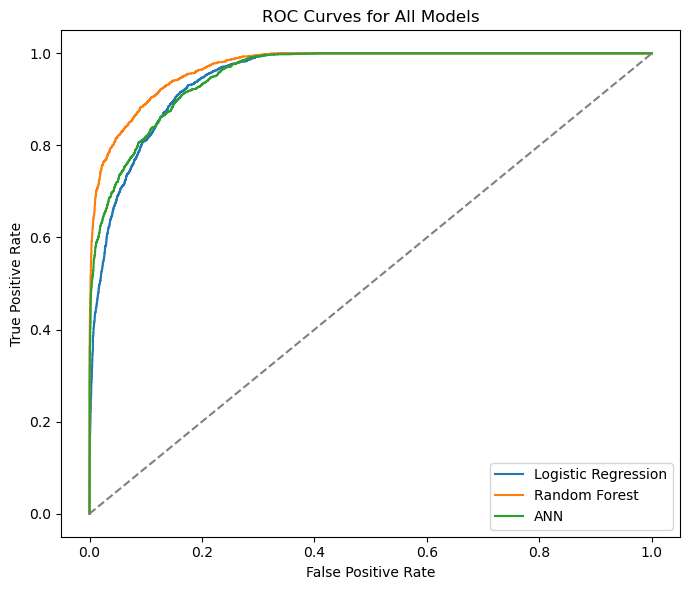

In [23]:
plt.figure(figsize=(7, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# ANN
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_probs)
plt.plot(fpr_mlp, tpr_mlp, label="ANN")

# Diagonal
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.tight_layout()
plt.show()


ROC curves are shown for visual comparison only. Model selection is based on
cross-validated ROC–AUC scores reported earlier, rather than visual inspection
of individual curves.


## 10. Final Model Selection

Across all experiments, Random Forest consistently achieved the strongest and most
stable performance under ROC–AUC. While Logistic Regression provided a strong linear
baseline and the neural network demonstrated competitive non-linear capacity, Random
Forest offered the best balance between predictive performance, robustness, and
practical deployability.

Accordingly, Random Forest is selected as the final recommended model.
